# ✈️ Flight Price Prediction
## Notebook 1: Exploratory Data Analysis (EDA)

**Цель:** Изучить датасет, понять структуру данных, выявить зависимости между признаками и ценой билета.

**Датасет:** [Flight Price Prediction — Kaggle](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction)

**Таргет:** `price` — стоимость авиабилета в рупиях

**Метрика:** RMSE (Root Mean Squared Error) — штрафует за большие ошибки, что важно при предсказании цен. Дополнительно смотрим на R² для понимания объяснённой дисперсии.

## 0. Импорты

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Фиксируем seed для воспроизводимости
SEED = 42
np.random.seed(SEED)

# Стиль графиков
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print('Импорты выполнены ✅')

Импорты выполнены ✅


## 1. Загрузка данных

In [2]:
# Скачай датасет с Kaggle и положи в папку data/raw/
# Файл называется: Clean_Dataset.csv
DATA_PATH = '../data/raw/Clean_Dataset.csv'

df = pd.read_csv(DATA_PATH)
print(f'Размер датасета: {df.shape[0]:,} строк, {df.shape[1]} колонок')
df.head()

Размер датасета: 300,153 строк, 12 колонок


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


## 2. Описание датасета

In [3]:
print('=== Типы данных и количество ненулевых значений ===')
df.info()

=== Типы данных и количество ненулевых значений ===
<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


In [4]:
print('=== Описание колонок ===')
col_descriptions = {
    'airline':         'Авиакомпания',
    'flight':          'Код рейса',
    'source_city':     'Город отправления',
    'departure_time':  'Время суток отправления (утро/день/вечер/ночь)',
    'stops':           'Количество пересадок',
    'arrival_time':    'Время суток прилёта',
    'destination_city':'Город назначения',
    'class':           'Класс обслуживания (Economy / Business)',
    'duration':        'Длительность полёта (в часах)',
    'days_left':       'Дней до вылета на момент покупки',
    'price':           'ТАРГЕТ: Цена билета (в рупиях)'
}
for col, desc in col_descriptions.items():
    print(f'  {col:<20} — {desc}')

=== Описание колонок ===
  airline              — Авиакомпания
  flight               — Код рейса
  source_city          — Город отправления
  departure_time       — Время суток отправления (утро/день/вечер/ночь)
  stops                — Количество пересадок
  arrival_time         — Время суток прилёта
  destination_city     — Город назначения
  class                — Класс обслуживания (Economy / Business)
  duration             — Длительность полёта (в часах)
  days_left            — Дней до вылета на момент покупки
  price                — ТАРГЕТ: Цена билета (в рупиях)


In [5]:
print('=== Статистика числовых признаков ===')
df.describe().round(2)

=== Статистика числовых признаков ===


,Unnamed: 0,duration,days_left,price
count,300153.00,300153.00,300153.00,300153.00
mean,150076.00,12.22,26.00,20889.66
std,86646.85,7.19,13.56,22697.77
min,0.00,0.83,1.00,1105.00
25%,75038.00,6.83,15.00,4783.00
50%,150076.00,11.25,26.00,7425.00
75%,225114.00,16.17,38.00,42521.00
max,300152.00,49.83,49.00,123071.00


In [6]:
print('=== Уникальные значения категориальных признаков ===')
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    vals = df[col].unique()
    print(f'  {col}: {list(vals)}')

=== Уникальные значения категориальных признаков ===
  airline: ['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
  flight: ['SG-8709', 'SG-8157', 'I5-764', 'UK-995', 'UK-963', 'UK-945', 'UK-927', 'UK-951', 'G8-334', 'G8-336', 'G8-392', 'G8-338', '6E-5001', '6E-6202', '6E-549', '6E-6278', 'AI-887', 'AI-665', 'I5-747', 'G8-266', 'G8-101', 'G8-103', 'AI-441', '6E-5328', 'UK-933', '6E-2046', 'I5-744', 'SG-8169', '6E-5041', 'G8-165', '6E-2373', 'UK-813', 'UK-817', 'UK-819', 'UK-801', 'UK-815', 'AI-453', 'SG-2976', 'AI-504', 'AI-502', 'AI-506', 'AI-803', 'AI-479', 'SG-339', 'UK-955', 'UK-627', 'I5-784', 'AI-9643', 'AI-540', 'AI-429', 'AI-439', 'AI-9645', '6E-2193', '6E-2168', '6E-152', '6E-369', 'UK-899', 'AI-764', 'UK-747', 'UK-809', 'UK-737', '6E-2338', 'G8-237', 'UK-871', 'AI-762', 'G8-1404', 'AI-512', 'AI-537', 'UK-977', '6E-184', 'SG-3002', '6E-2102', 'AI-801', 'UK-637', 'UK-835', 'AI-531', 'UK-705', 'UK-707', 'UK-673', 'AI-839', 'UK-879', 'G8-191', 'AI-767', 'AI-40

## 3. Проверка качества данных

In [7]:
print('=== Пропущенные значения ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
print(missing_df[missing_df['count'] > 0])
if missing.sum() == 0:
    print('Пропусков нет ✅')

=== Пропущенные значения ===
Empty DataFrame
Columns: [count, percent]
Index: []
Пропусков нет ✅


In [8]:
print('=== Дубликаты ===')
dupes = df.duplicated().sum()
print(f'Количество полных дублей: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'Удалено дублей: {dupes}. Новый размер: {df.shape}')

=== Дубликаты ===
Количество полных дублей: 0


## 4. Анализ таргета: цена билета

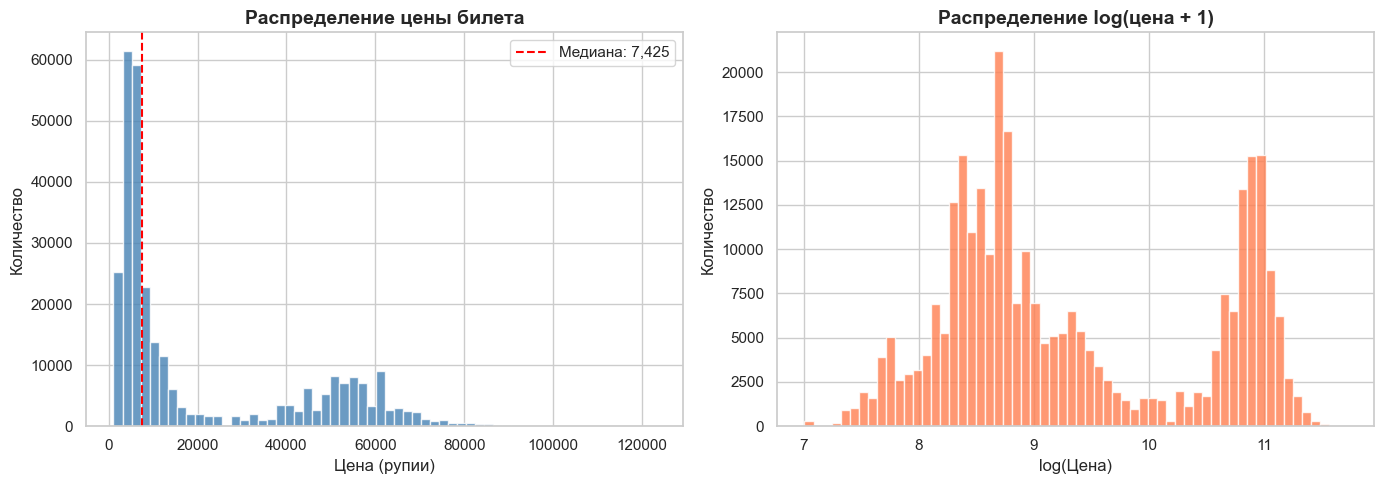

Мин: 1,105 | Макс: 123,071
Медиана: 7,425.0 | Среднее: 20,890
Std: 22,698


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение цены
axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Распределение цены билета', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Цена (рупии)')
axes[0].set_ylabel('Количество')
axes[0].axvline(df['price'].median(), color='red', linestyle='--', label=f'Медиана: {df["price"].median():,.0f}')
axes[0].legend()

# Логарифм цены (часто помогает при обучении)
axes[1].hist(np.log1p(df['price']), bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Распределение log(цена + 1)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Цена)')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.savefig('../data/plots/price_distribution.png', bbox_inches='tight')
plt.show()

print(f'Мин: {df["price"].min():,} | Макс: {df["price"].max():,}')
print(f'Медиана: {df["price"].median():,} | Среднее: {df["price"].mean():,.0f}')
print(f'Std: {df["price"].std():,.0f}')

## 5. Цена по категориальным признакам

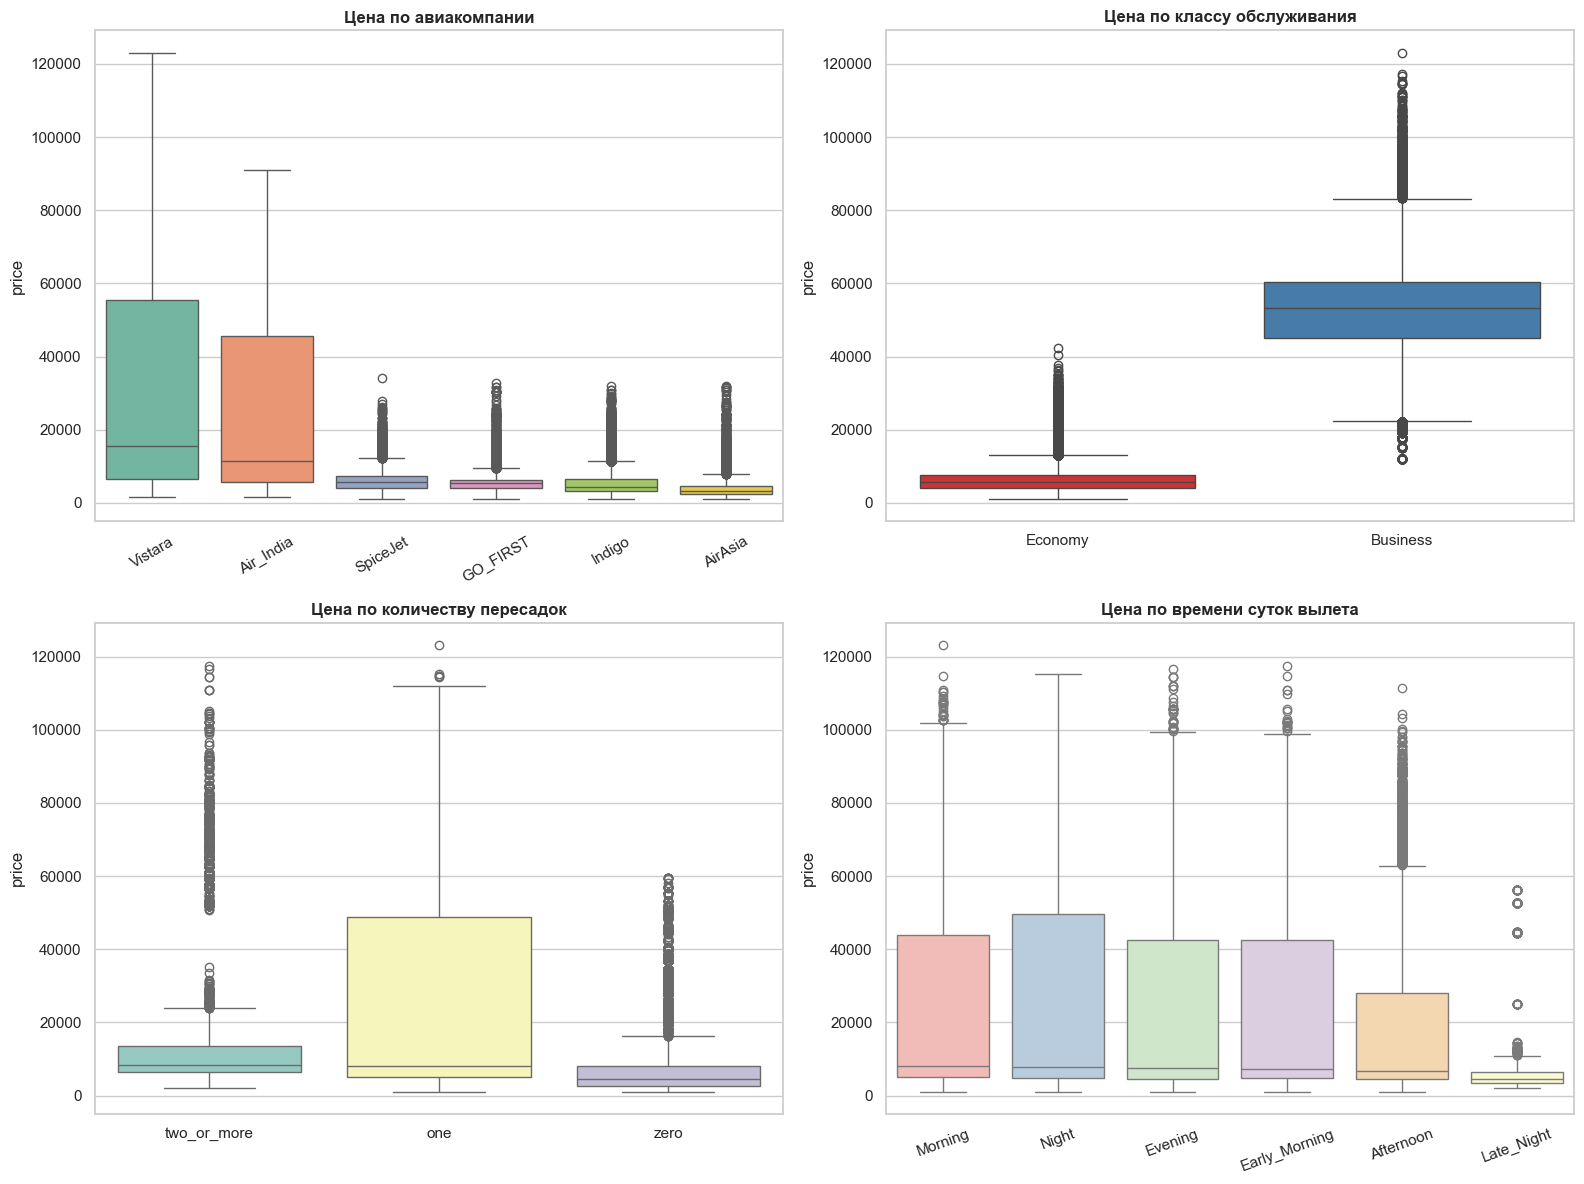

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# По авиакомпании
order = df.groupby('airline')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='airline', y='price', order=order, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Цена по авиакомпании', fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=30)

# По классу
sns.boxplot(data=df, x='class', y='price', ax=axes[0,1], palette='Set1')
axes[0,1].set_title('Цена по классу обслуживания', fontweight='bold')
axes[0,1].set_xlabel('')

# По пересадкам
order_stops = df.groupby('stops')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='stops', y='price', order=order_stops, ax=axes[1,0], palette='Set3')
axes[1,0].set_title('Цена по количеству пересадок', fontweight='bold')
axes[1,0].set_xlabel('')

# По времени отправления
order_dep = df.groupby('departure_time')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='departure_time', y='price', order=order_dep, ax=axes[1,1], palette='Pastel1')
axes[1,1].set_title('Цена по времени суток вылета', fontweight='bold')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../data/plots/price_by_categories.png', bbox_inches='tight')
plt.show()

## 6. Цена и числовые признаки

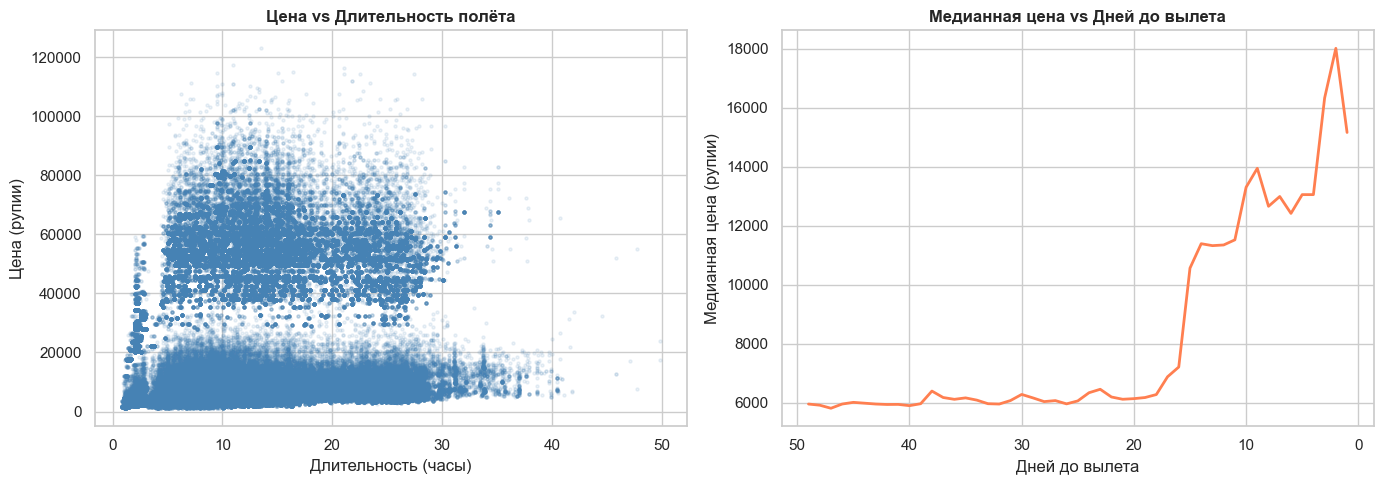

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Цена vs длительность полёта
axes[0].scatter(df['duration'], df['price'], alpha=0.1, s=5, color='steelblue')
axes[0].set_title('Цена vs Длительность полёта', fontweight='bold')
axes[0].set_xlabel('Длительность (часы)')
axes[0].set_ylabel('Цена (рупии)')

# Цена vs дней до вылета
# Усредним по дням для наглядности
avg_by_days = df.groupby('days_left')['price'].median().reset_index()
axes[1].plot(avg_by_days['days_left'], avg_by_days['price'], color='coral', linewidth=2)
axes[1].set_title('Медианная цена vs Дней до вылета', fontweight='bold')
axes[1].set_xlabel('Дней до вылета')
axes[1].set_ylabel('Медианная цена (рупии)')
axes[1].invert_xaxis()  # чем меньше дней, тем ближе к вылету

plt.tight_layout()
plt.savefig('../data/plots/price_vs_numeric.png', bbox_inches='tight')
plt.show()

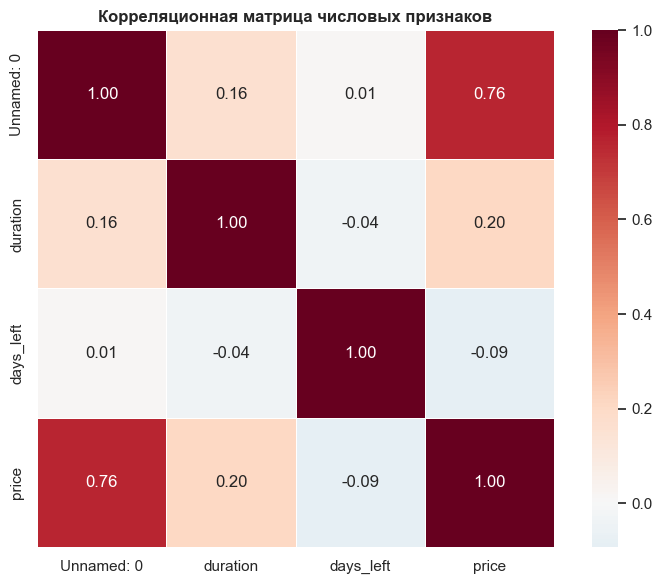

In [12]:
# Тепловая карта корреляций (только числовые)
num_cols = df.select_dtypes(include='number').columns
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plots/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Анализ маршрутов

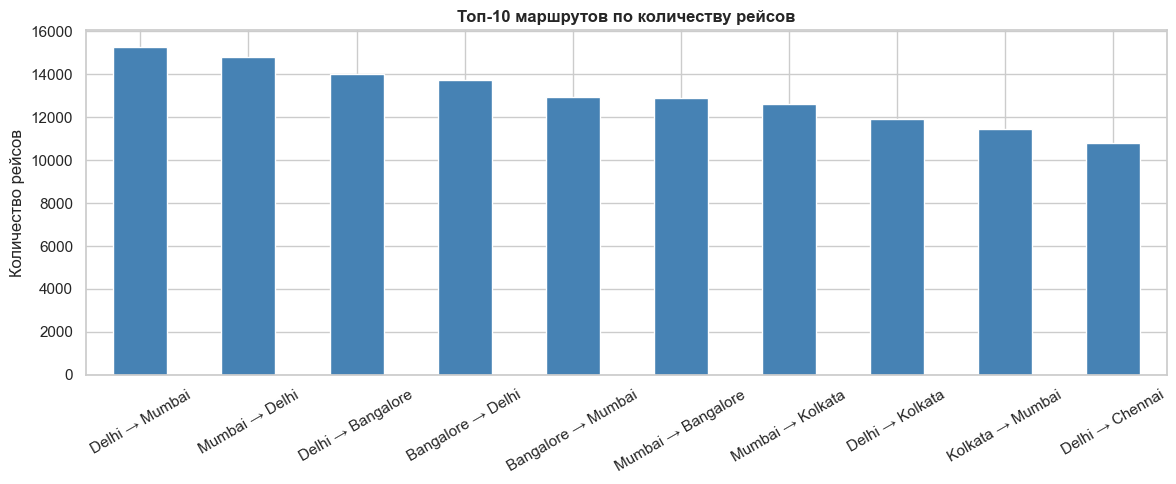

In [13]:
# Создаём признак маршрута
df['route'] = df['source_city'] + ' → ' + df['destination_city']

# Топ маршрутов по количеству рейсов
top_routes = df['route'].value_counts().head(10)
plt.figure(figsize=(12, 5))
top_routes.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Топ-10 маршрутов по количеству рейсов', fontweight='bold')
plt.xlabel('')
plt.ylabel('Количество рейсов')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../data/plots/top_routes.png', bbox_inches='tight')
plt.show()

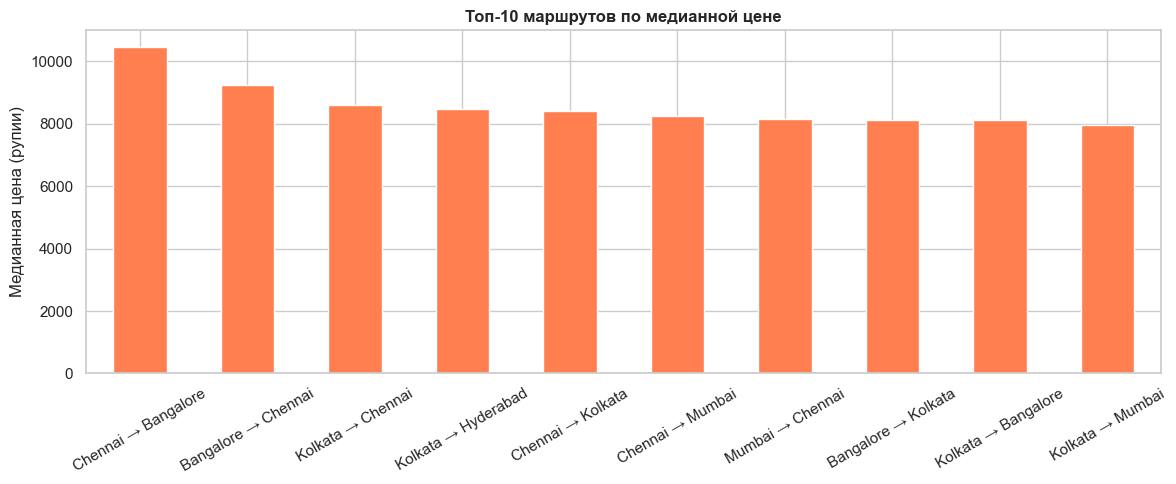

In [14]:
# Средняя цена по маршрутам
route_prices = df.groupby('route')['price'].median().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
route_prices.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Топ-10 маршрутов по медианной цене', fontweight='bold')
plt.xlabel('')
plt.ylabel('Медианная цена (рупии)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../data/plots/route_prices.png', bbox_inches='tight')
plt.show()

## 8. Выводы EDA

- **Распределение цены** правостороннее — есть дорогие выбросы. Логарифмирование сглаживает распределение.
- **Класс** — самый сильный предиктор: Business сильно дороже Economy.
- **Авиакомпания** влияет на цену.
- **Дней до вылета** — чем меньше, тем дороже (особенно < 20 дней).
- **Пересадки** — рейсы с пересадками не всегда дешевле, зависит от маршрута.
- **Пропусков нет**, качество данных хорошее.